# Unconfoundedness

We call 'Uncofoundedness' a scenario where a treatment is not randomly assigned to participants, so confounders effect on treatment assignment and outcome. We have client - level data. Confounders were measured before treatment and outcome after

Let's look at the example:

In our ecosystem we have a product, which effect on LTV we want to estimate

Treatment - first purchase in product.

Outcome - LTV after first purchase.

We will test hypothesis:

$H_o$ - There is no difference in LTV between treatment and control groups.

$H_a$ - There is a difference in LTV between treatment and control groups.

# Causal Assumptions

**Unconfoundedness**: We control all confounders

**Overlap**: propensity distributions overlap

**SUTVA**: no interference and consistent treatment definitions. By design

**DML works correctly**: nuisance functions are correctly specified

**No leakage**: confounders are measured before treatment

# Data

For the analysis you need data in pandas dataframe:
- treatment column in binary format (1/0)
- outcome column numeric format, measured after treatment time
- user_id column (Optional, but useful)
- confounders columns (Optional, measured before treatment time, numeric format, used for causal assumption check)

We will take data from Causalis DGP.. Read more at https://causalis.causalcraft.com/articles/generate_obs_hte_26_rich

In [1]:
from causalis.scenarios.unconfoundedness.dgp import generate_obs_hte_26_rich

data = generate_obs_hte_26_rich(return_causal_data=False, include_oracle=True)
data.head()

,user_id,y,d,tenure_months,avg_sessions_week,spend_last_month,age_years,income_monthly,prior_purchases_12m,support_tickets_90d,premium_user,mobile_user,urban_resident,referred_user,m,m_obs,tau_link,g0,g1,cate
0,1,0.000000,0.0,28.814654,1.0,77.936767,50.234101,1926.698301,1.0,2.0,1.0,1.0,1.0,0.0,0.045453,0.045453,0.089095,8.137981,9.142395,1.004414
1,2,80.099611,1.0,25.913345,3.0,53.777740,28.115859,5104.271509,3.0,0.0,1.0,1.0,0.0,1.0,0.041514,0.041514,0.246679,60.459257,78.817307,18.358049
2,3,6.400482,1.0,24.969929,10.0,134.764322,22.907062,5267.938255,8.0,3.0,0.0,1.0,1.0,0.0,0.052593,0.052593,0.162968,7.712855,9.138577,1.425723
3,4,2.788238,0.0,40.655089,5.0,59.517074,31.970490,6597.327018,3.0,2.0,1.0,1.0,1.0,0.0,0.036221,0.036221,0.188755,25.386510,31.159932,5.773422
4,5,0.000000,0.0,18.560899,3.0,74.370930,39.237248,4930.009628,5.0,1.0,1.0,1.0,0.0,0.0,0.036343,0.036343,0.174757,15.359250,18.600227,3.240977


In [2]:
from causalis.data_contracts import CausalData

causaldata = CausalData(df = data,
                        user_id='user_id',
                        treatment='d',
                        outcome='y',
                        confounders=['tenure_months',
                                     'avg_sessions_week',
                                     'spend_last_month',
                                     'age_years',
                                     'income_monthly',
                                     'prior_purchases_12m',
                                     'support_tickets_90d',
                                     'premium_user',
                                     'mobile_user',
                                     'urban_resident',
                                     'referred_user'])
causaldata

CausalData(df=(100000, 14), treatment='d', outcome='y', confounders=['tenure_months', 'avg_sessions_week', 'spend_last_month', 'age_years', 'income_monthly', 'prior_purchases_12m', 'support_tickets_90d', 'premium_user', 'mobile_user', 'urban_resident', 'referred_user'], user_id='user_id')

# EDA

In [3]:
from causalis.shared import outcome_stats
outcome_stats(causaldata)

,treatment,count,mean,std,min,p10,p25,median,p75,p90,max
0,0,95051,76.087138,240.800713,0.0,0.0,0.0,8.39544,64.859278,190.227900,21396.007575
1,1,4949,58.506172,199.485625,0.0,0.0,0.0,0.00000,36.958280,148.837193,5143.642132


Our data has strong treatment class disbalance. Only 5% of sample activated in treatment.

Treatment group has lower mean LTV. It's too early to draw conclusions.

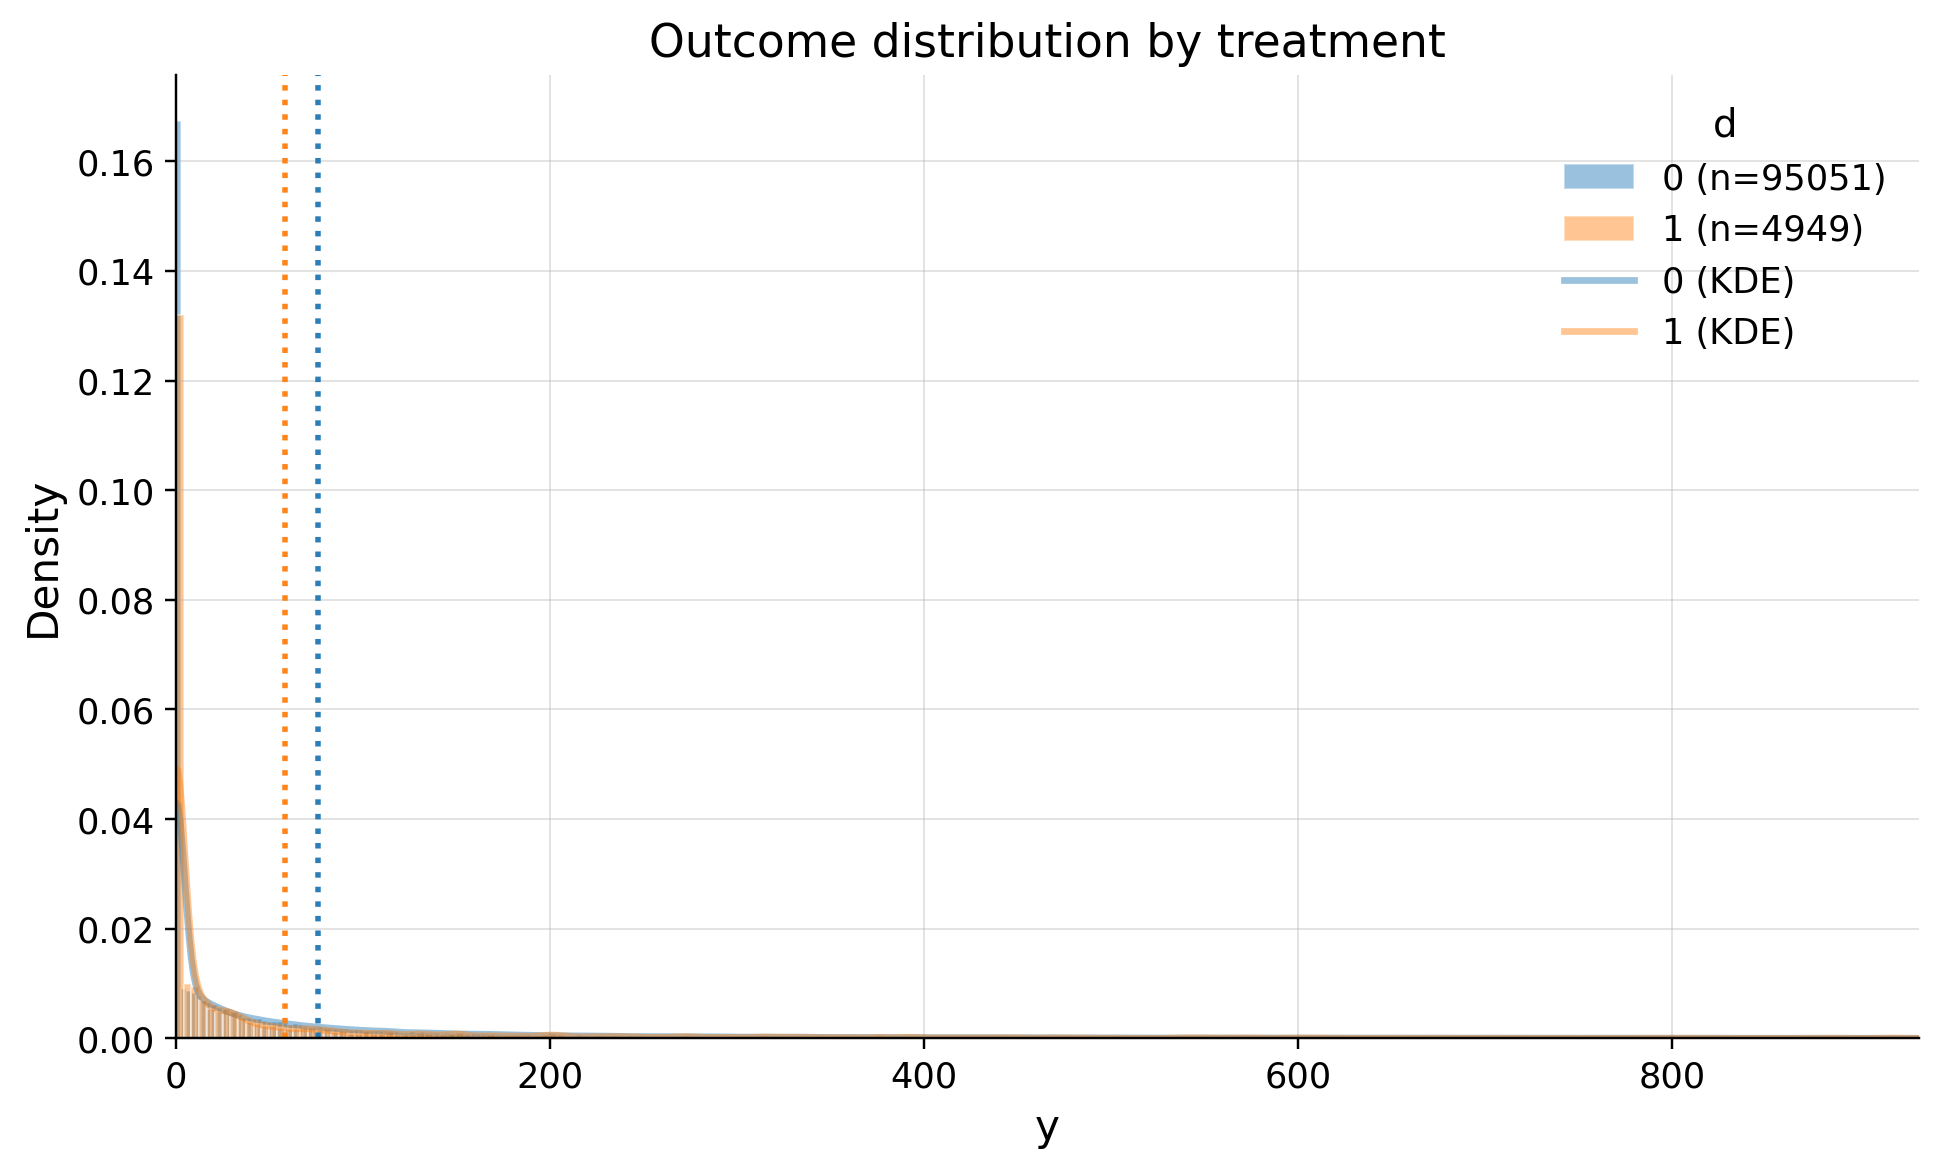

In [4]:
from causalis.shared.outcome_plots import outcome_plot_dist
outcome_plot_dist(causaldata)

We see large right tale

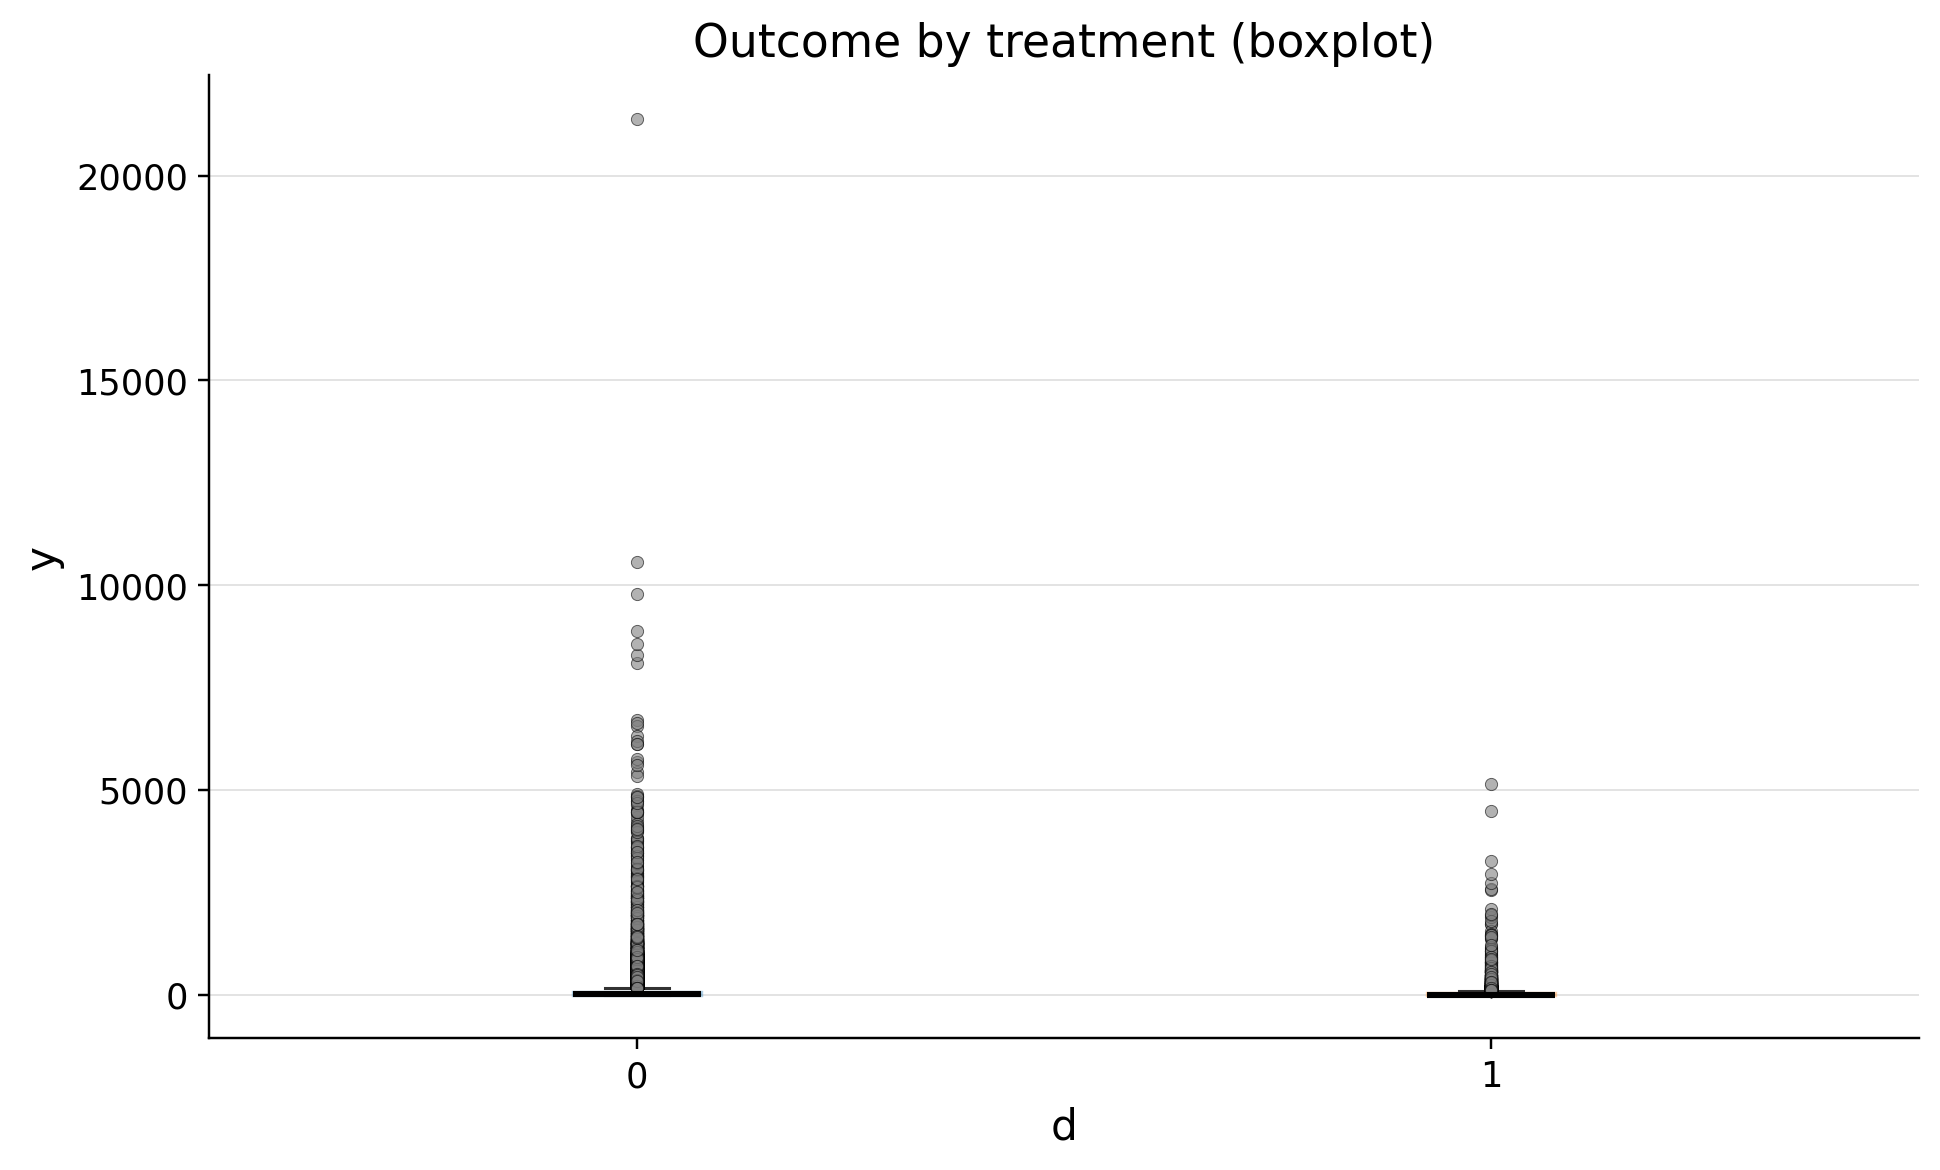

In [5]:
from causalis.shared.outcome_plots import outcome_plot_boxplot
outcome_plot_boxplot(causaldata)

In [6]:
from causalis.shared import outcome_outliers

outcome_outliers(causaldata)

,treatment,n,outlier_count,outlier_rate,lower_bound,upper_bound,has_outliers,method,tail
0,0,95051,11300,0.118884,-97.288916,162.148194,True,iqr,both
1,1,4949,721,0.145686,-55.437420,92.395699,True,iqr,both


We see many outliers. It's common situation for LTV metric. Dropping them will lead to a biased conclusion

In [7]:
from causalis.shared import confounders_balance

confounders_balance(causaldata)

,confounders,mean_d_0,mean_d_1,abs_diff,smd,ks_pvalue
0,premium_user,0.751807,0.591837,0.159970,-0.345721,0.00000
1,income_monthly,4549.385190,3918.058798,631.326392,-0.277611,0.00000
2,spend_last_month,89.091801,67.375389,21.716412,-0.268360,0.00000
3,support_tickets_90d,0.984545,1.259244,0.274699,0.253974,0.00000
4,avg_sessions_week,5.047753,4.230148,0.817606,-0.201735,0.00000
5,prior_purchases_12m,3.904220,3.513639,0.390581,-0.189372,0.00000
6,tenure_months,28.740100,25.559161,3.180939,-0.184156,0.00000
7,age_years,36.435984,34.809083,1.626901,-0.144142,0.00000
8,referred_user,0.271486,0.307133,0.035647,0.078671,0.00001
9,urban_resident,0.600793,0.568802,0.031991,-0.064954,0.00013


As we see clients are differ on this confounders. We need to controll them to make causal inference

# Inference

ATTE is right estimand here. We will estimate effect on clients that were treated, had first purchase in our product

Read more about DML at https://causalis.causalcraft.com/articles/unconfoundedness-model

In [8]:
from causalis.scenarios.unconfoundedness import IRM

model = IRM(n_jobs=-1).fit(causaldata)

In [9]:
dml_result = model.estimate(score='ATTE')
dml_result.summary()

,value
field,
estimand,ATTE
model,IRM
value,"12.1722 (ci_abs: 7.6837, 16.6607)"
value_relative,"26.2706 (ci_rel: 16.4660, 36.0752)"
alpha,0.0500
p_value,0.0000
is_significant,True
n_treated,4949
n_control,95051


Our estimate is 12.1542 dollars (ci_abs: 7.7933, 16.5152). Mean in treatment group is 58.5062 dollars, so without our product it would be 46.3520 dollars.

# Refutation

## Unconfoundedness

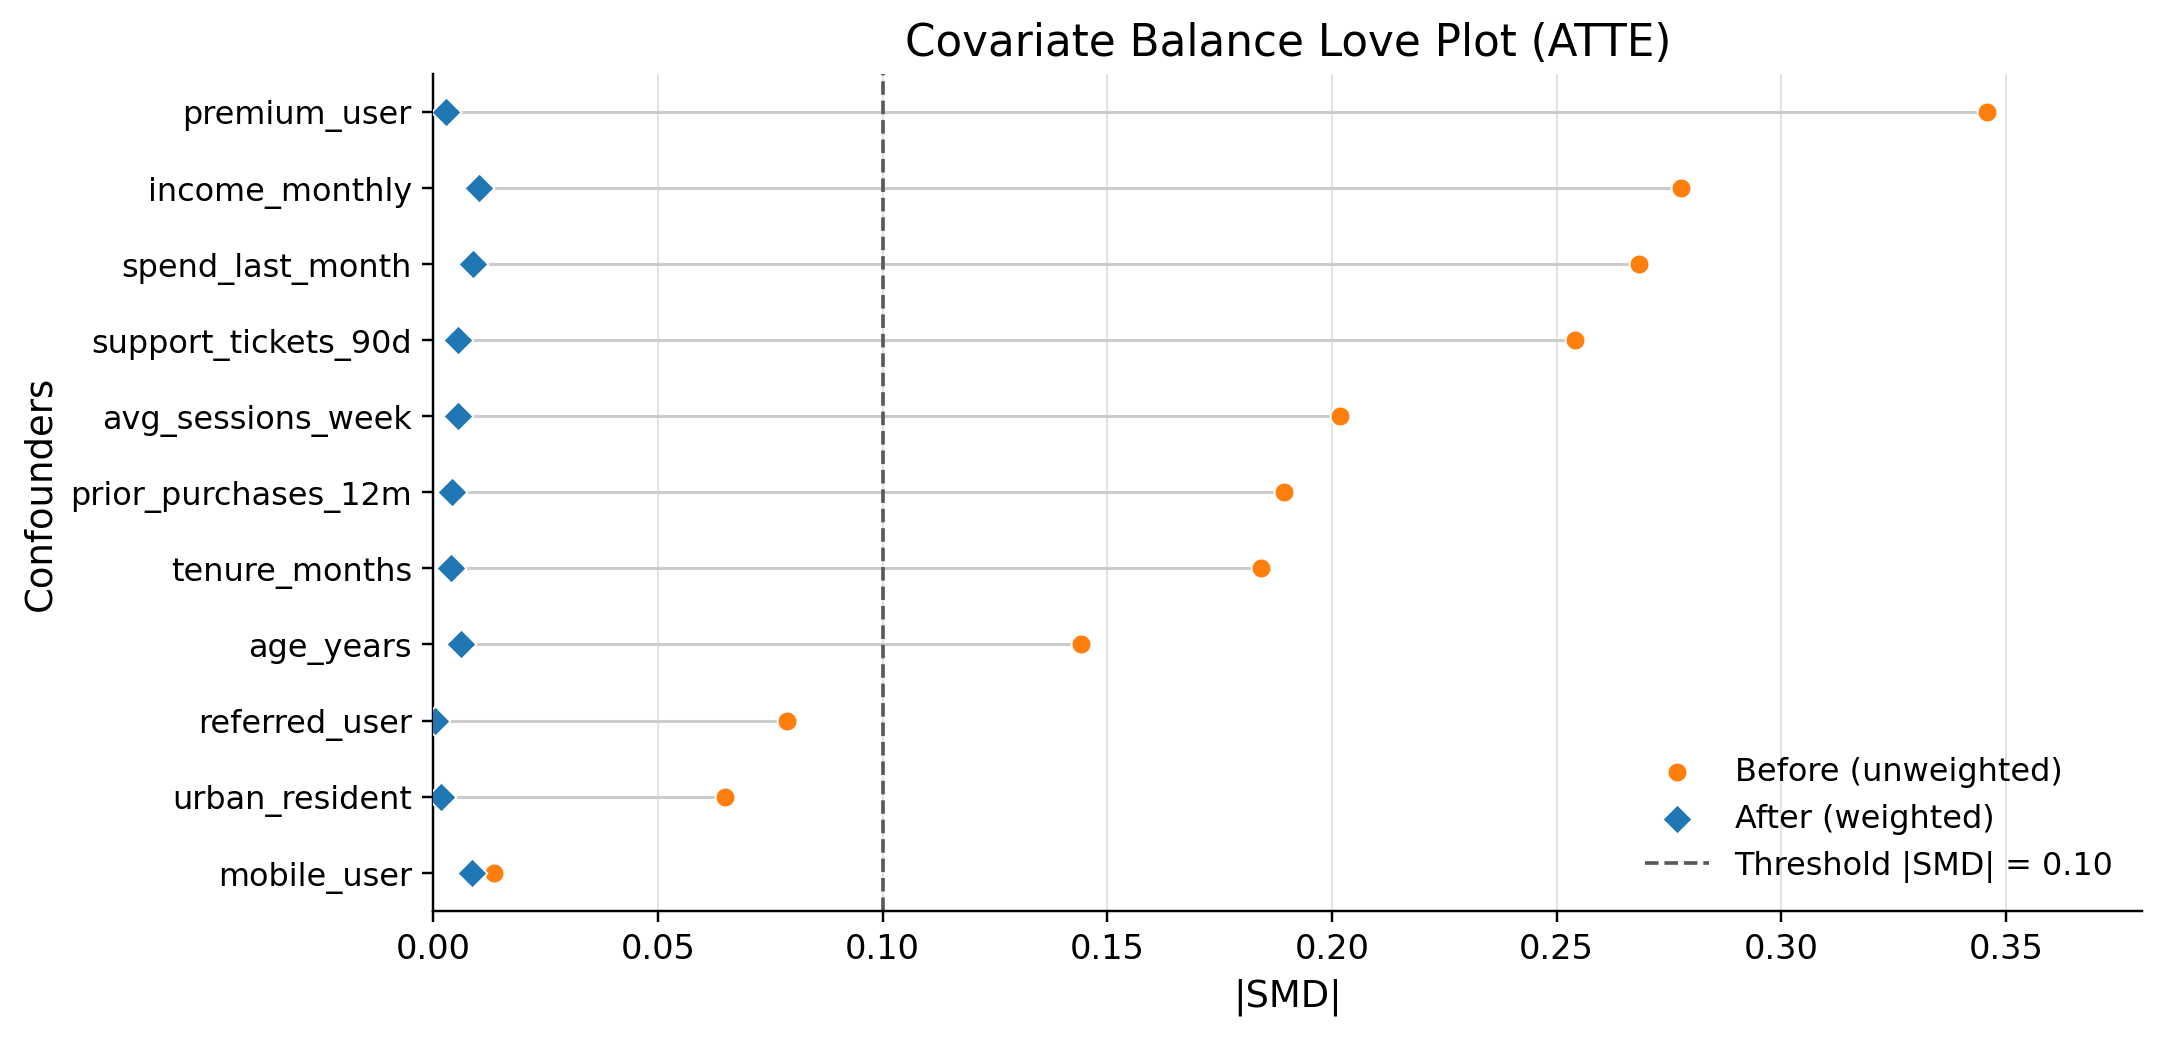

In [10]:
from causalis.scenarios.unconfoundedness.refutation import love_plot

love_plot(causaldata ,dml_result)

balance_max_smd is 0.011635 so dml specification dealt with controlling confounders

### Sensitivity

In [11]:
from causalis.scenarios.unconfoundedness.refutation.unconfoundedness.sensitivity import (
    sensitivity_analysis, sensitivity_benchmark
)

In [12]:
sensitivity_benchmark(dml_result, causaldata,  benchmarking_set =['tenure_months', 'premium_user'])

,benchmark_confounder,r2_y,r2_d,rho,theta_long,theta_short,delta
0,tenure_months,0.000263,0.044254,1.0,12.172204,11.010901,1.161303
1,premium_user,0.000459,0.225835,1.0,12.172204,8.767687,3.404517


In [13]:
sensitivity_analysis(dml_result, r2_y=0.000079, r2_d=0.048984, rho=1.0, alpha=0.05).summary()

,statistics,value
0,bias_aware_ci,"[5.9616, 18.3868]"
1,theta,"[10.452, 12.1722, 13.8924]"
2,sampling_ci,"[7.6837, 16.6607]"
3,rv,0.0141
4,rva,0.0089
5,se,2.2901
6,max_bias,1.7202
7,max_bias_base,852.7164
8,bound_width,1.7202
9,sigma2,34874.1955


Even if we have latent confounder as strong as 'tenure_months' our estimate will be > 0 with bias_aware_ci': (4.646164852659804, 18.5265291001404)

## SUTVA

In [14]:
from causalis.shared import print_sutva_questions
print_sutva_questions()

1.) Are your clients independent (i). Outcome of ones do not depend on others?
2.) Are all clients have full window to measure metrics?
3.) Do you measure confounders before treatment and outcome after?
4.) Do you have a consistent label of treatment, such as if a person does not receive a treatment, he has a label 0?


SUTVA is untestable from data alone, so we call it true by design

## Score

In [15]:
from causalis.scenarios.unconfoundedness.refutation.score.score_validation import run_score_diagnostics
rep_score = run_score_diagnostics(causaldata, dml_result)
rep_score["summary"]

,metric,value,flag
0,psi_p99_over_med,65.150475,RED
1,psi_kurtosis,2632.264875,RED
2,max_|t|_g0,0.689468,GREEN
3,max_|t|_m,1.450722,GREEN
4,oos_max_abs_t,0.000331,GREEN


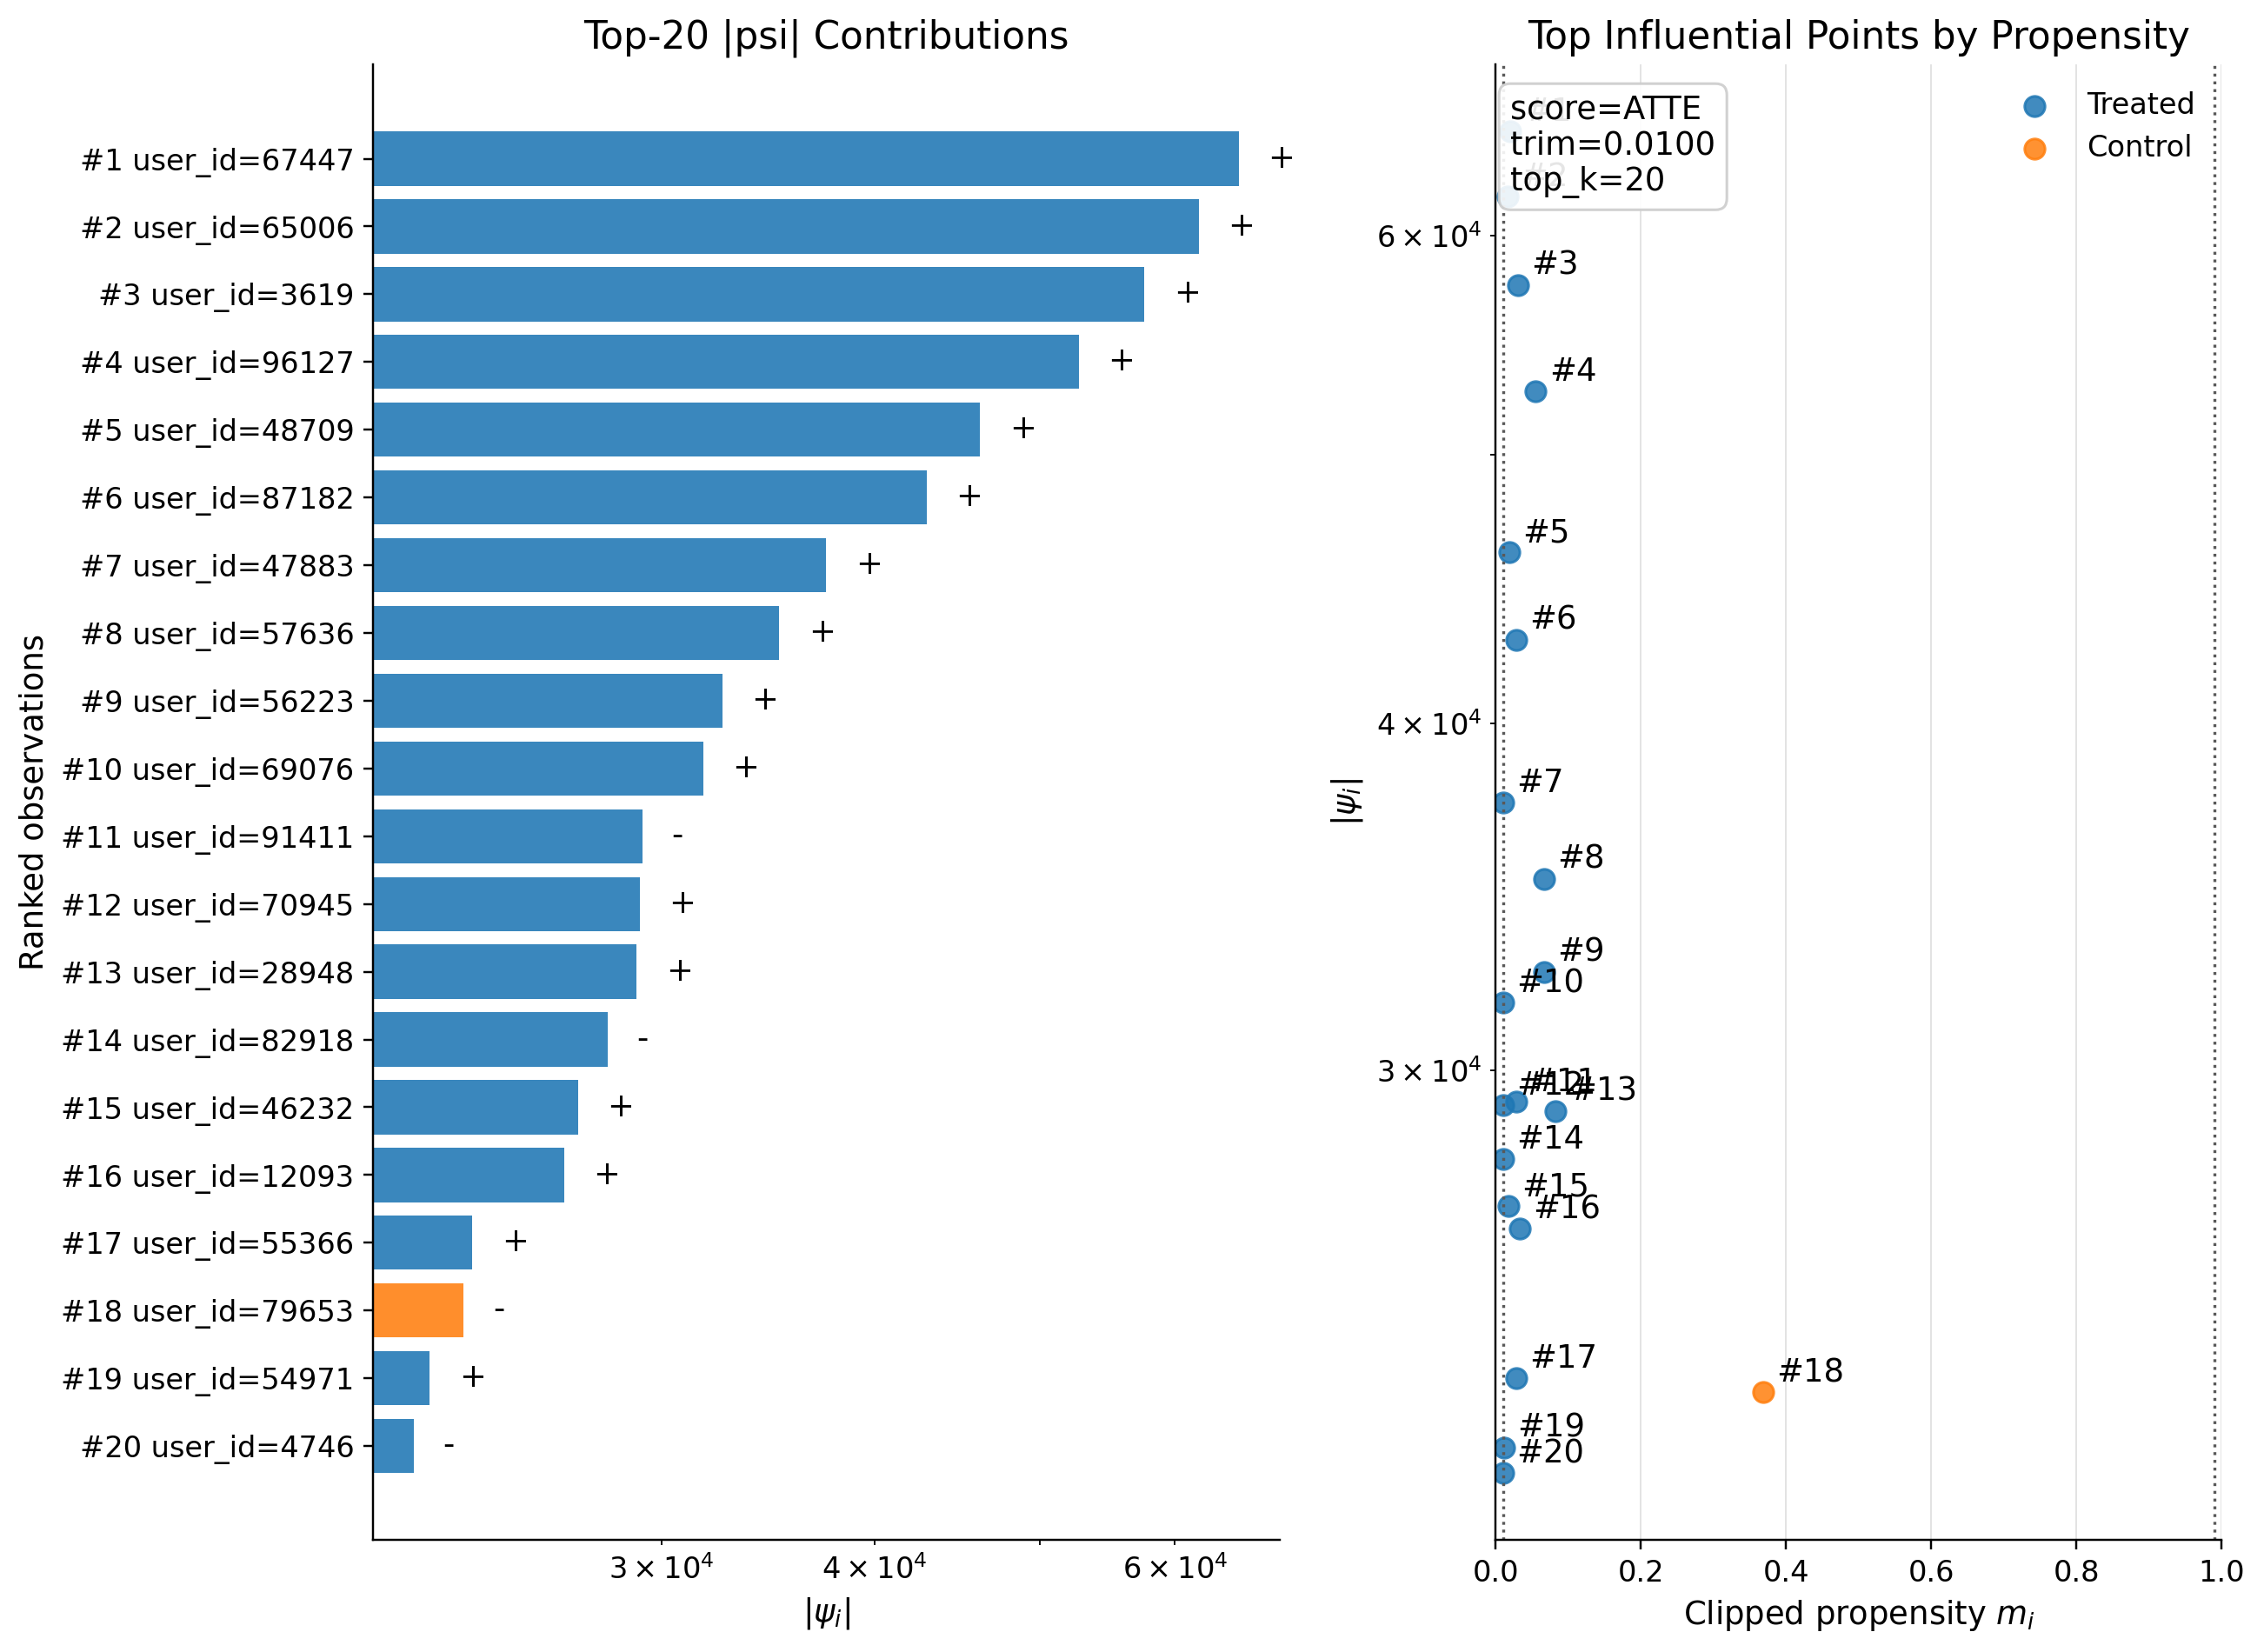

In [16]:
from causalis.scenarios.unconfoundedness.refutation import plot_influence_instability
plot_influence_instability(dml_result)

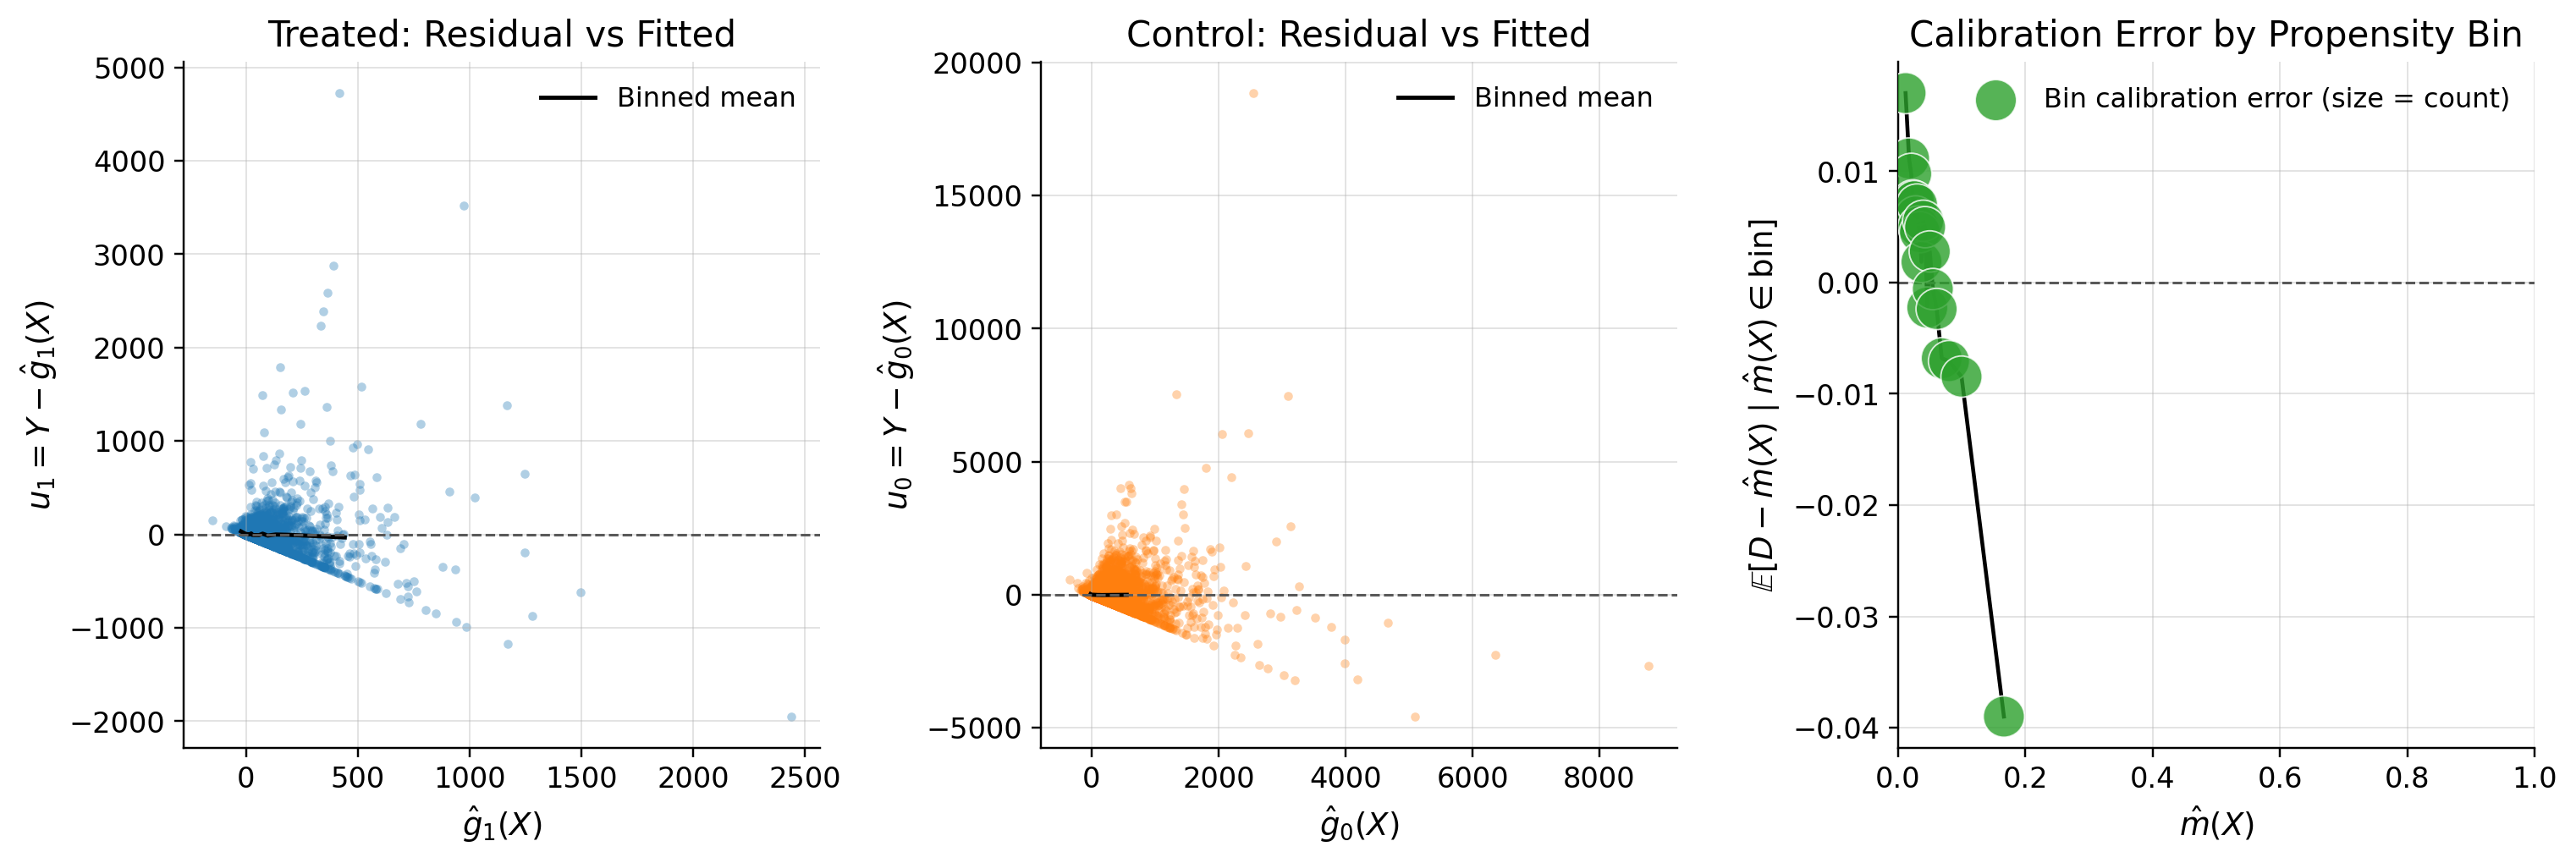

In [17]:
from causalis.scenarios.unconfoundedness.refutation import plot_residual_diagnostics
plot_residual_diagnostics(dml_result,
                          max_scatter_points=50000,
                          random_state=42)

DML is specified correctly. There are many outliers in data that effect the score

## Overlap

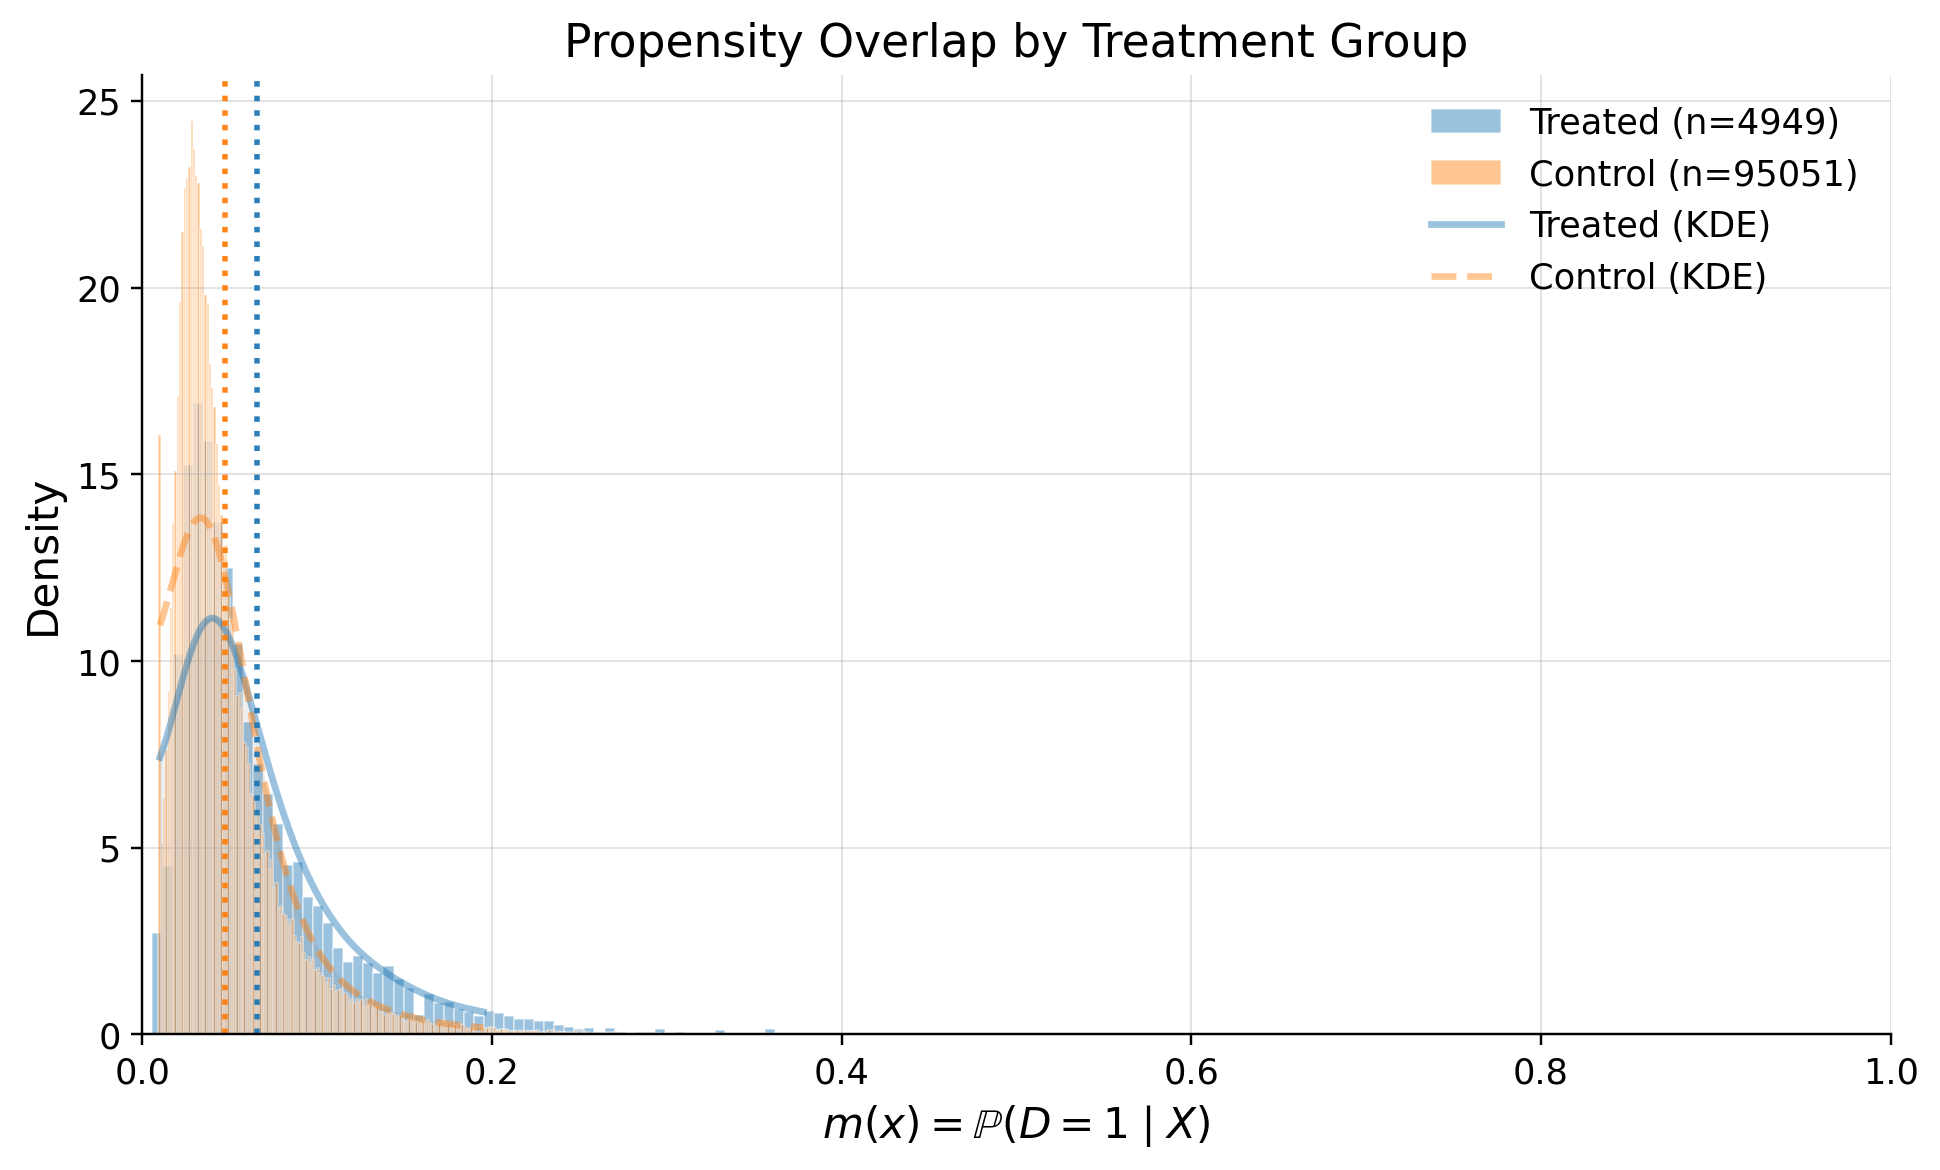

In [18]:
from causalis.scenarios.unconfoundedness.refutation import plot_m_overlap
plot_m_overlap(dml_result)

Customers are not inclined to activate the our product

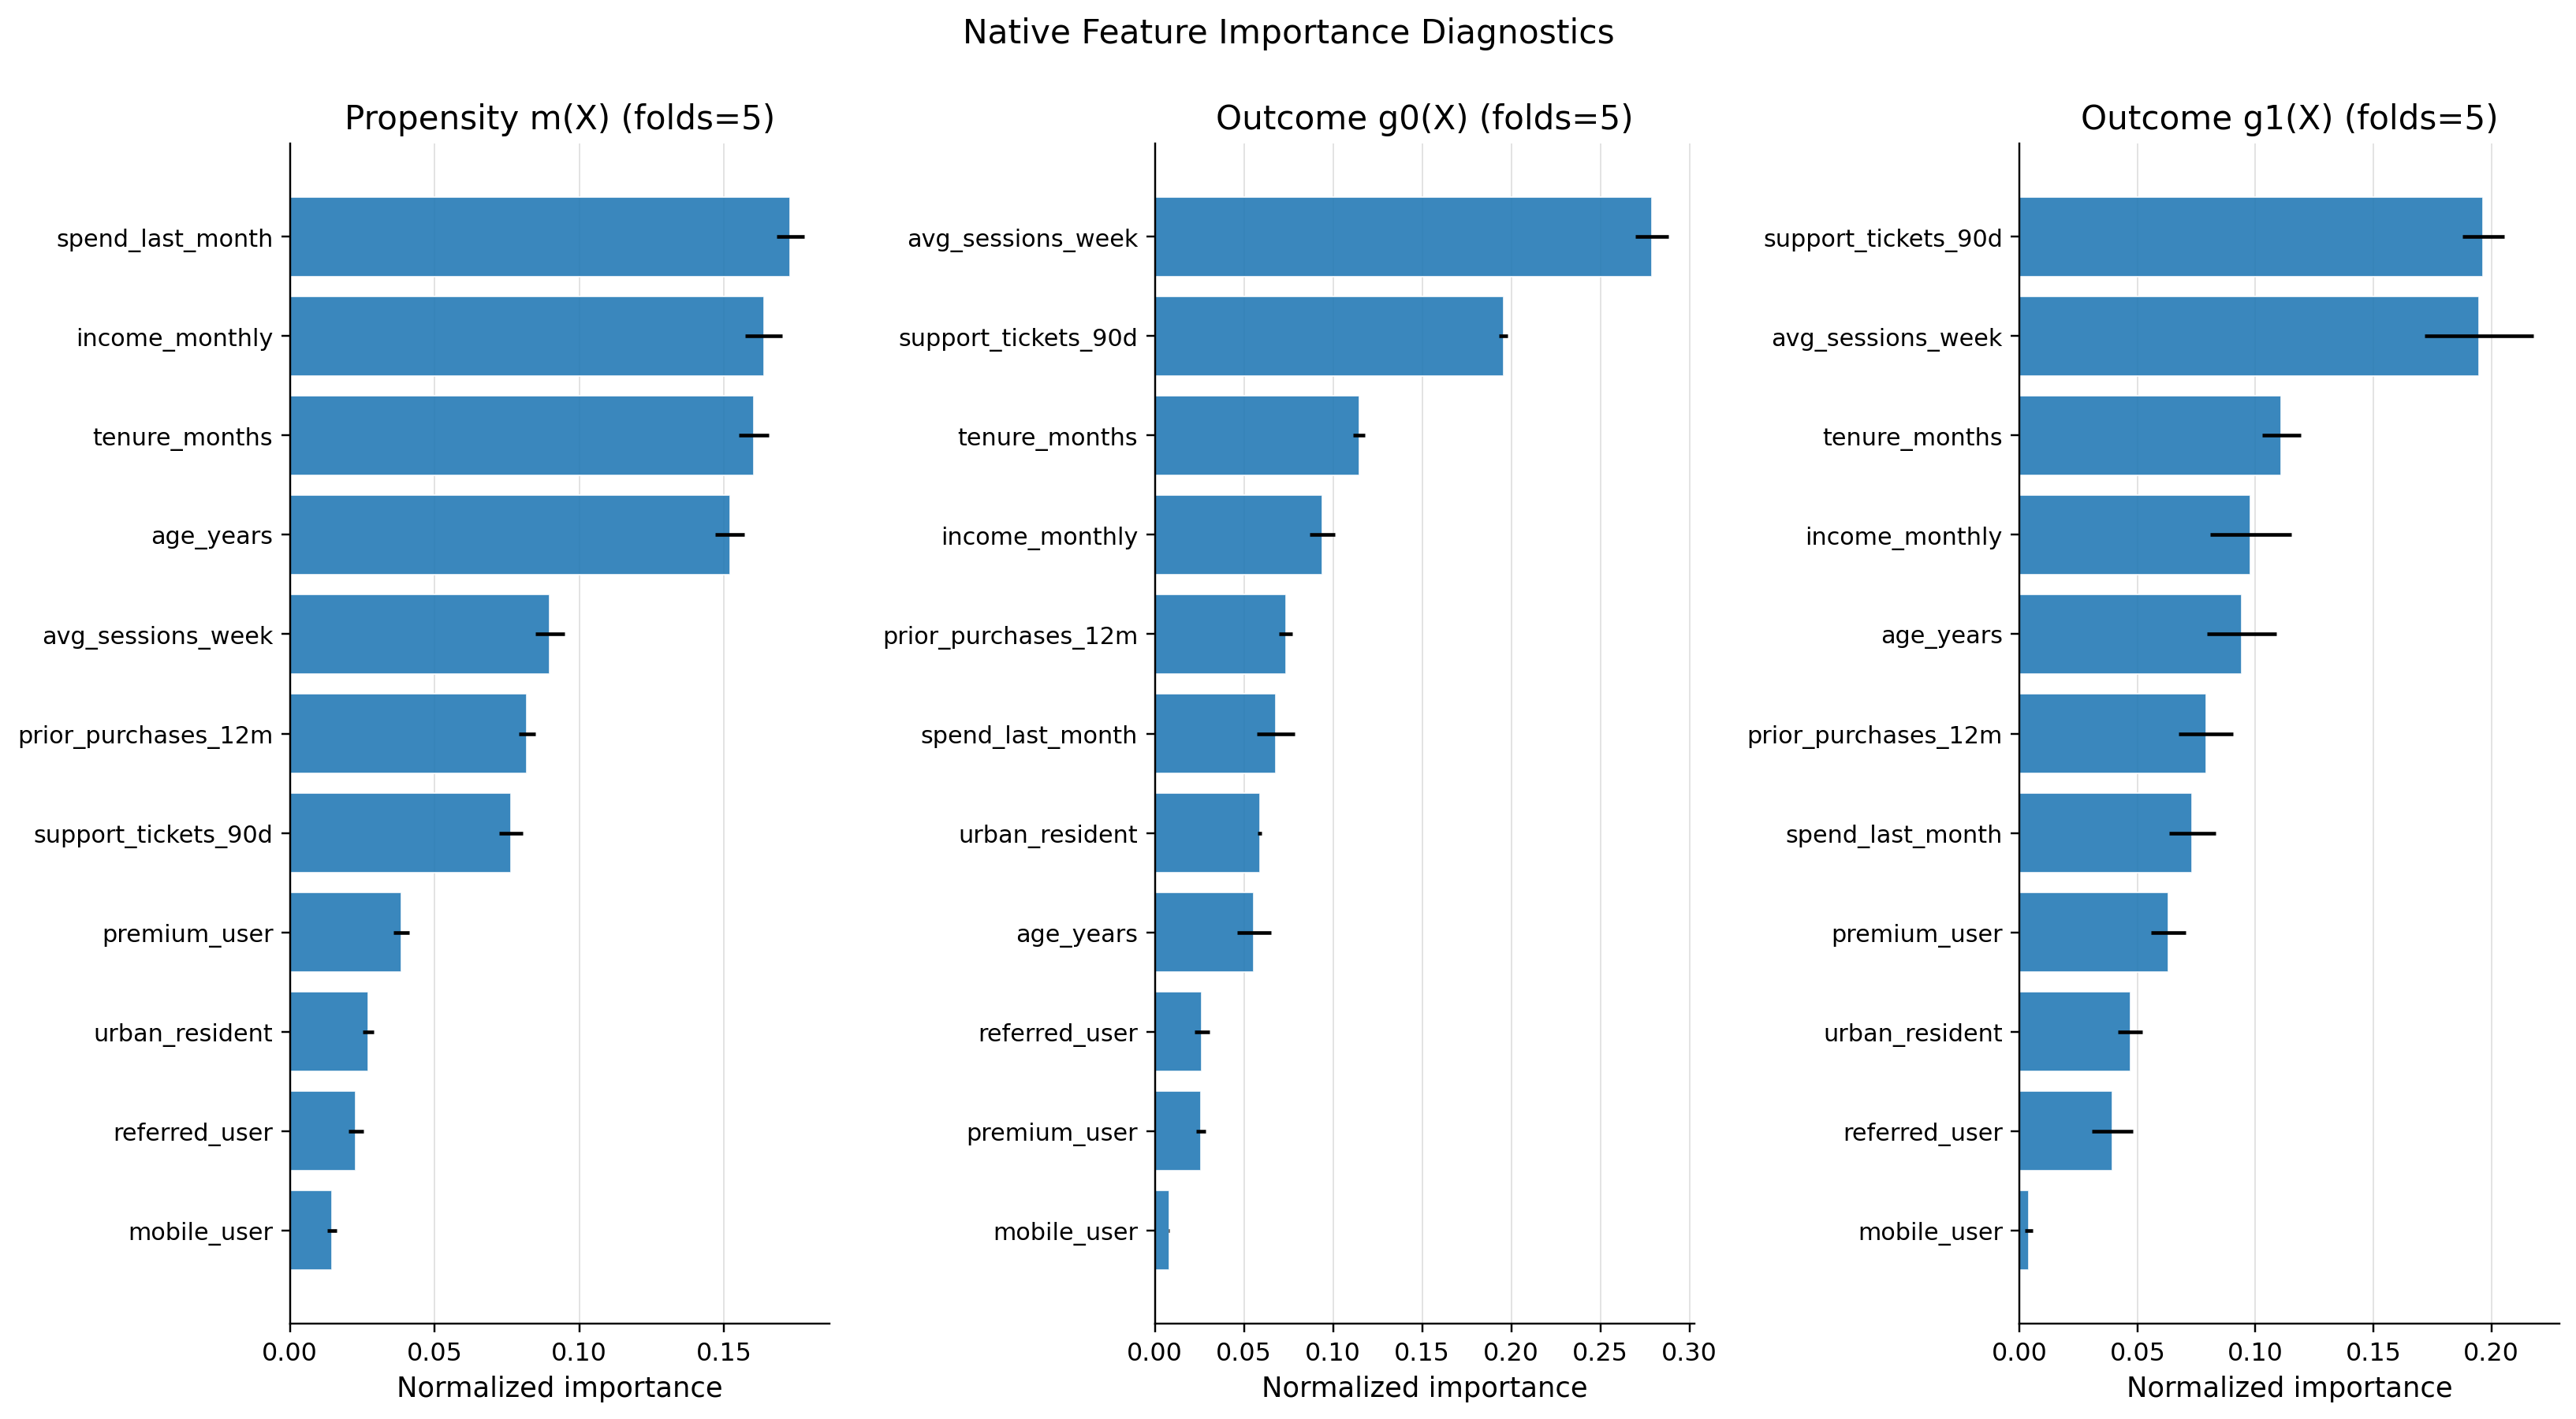

In [19]:
from causalis.scenarios.unconfoundedness.refutation.overlap import plot_feature_importance
plot_feature_importance(dml_result, top_k=20)

In [20]:
from causalis.scenarios.unconfoundedness.refutation import run_overlap_diagnostics
rep = run_overlap_diagnostics(causaldata, dml_result)
core = rep["summary"][rep["summary"]["metric"].isin([
    "edge_0.01_below",
    "edge_0.01_above",
    "KS",
    "ESS_treated_ratio",
    "ESS_control_ratio",
    "calib_ECE",
    "ATT_identity_relerr"
])]
core

,metric,value,flag
0,edge_0.01_below,0.018360,GREEN
1,edge_0.01_above,0.000000,GREEN
4,KS,0.184032,GREEN
6,ESS_treated_ratio,0.522373,GREEN
7,ESS_control_ratio,0.997905,GREEN
10,ATT_identity_relerr,0.011421,GREEN
12,calib_ECE,0.005636,GREEN


if calib_ECE is YELLOW/RED look at `plot_propensity_reliability(dml_result)`

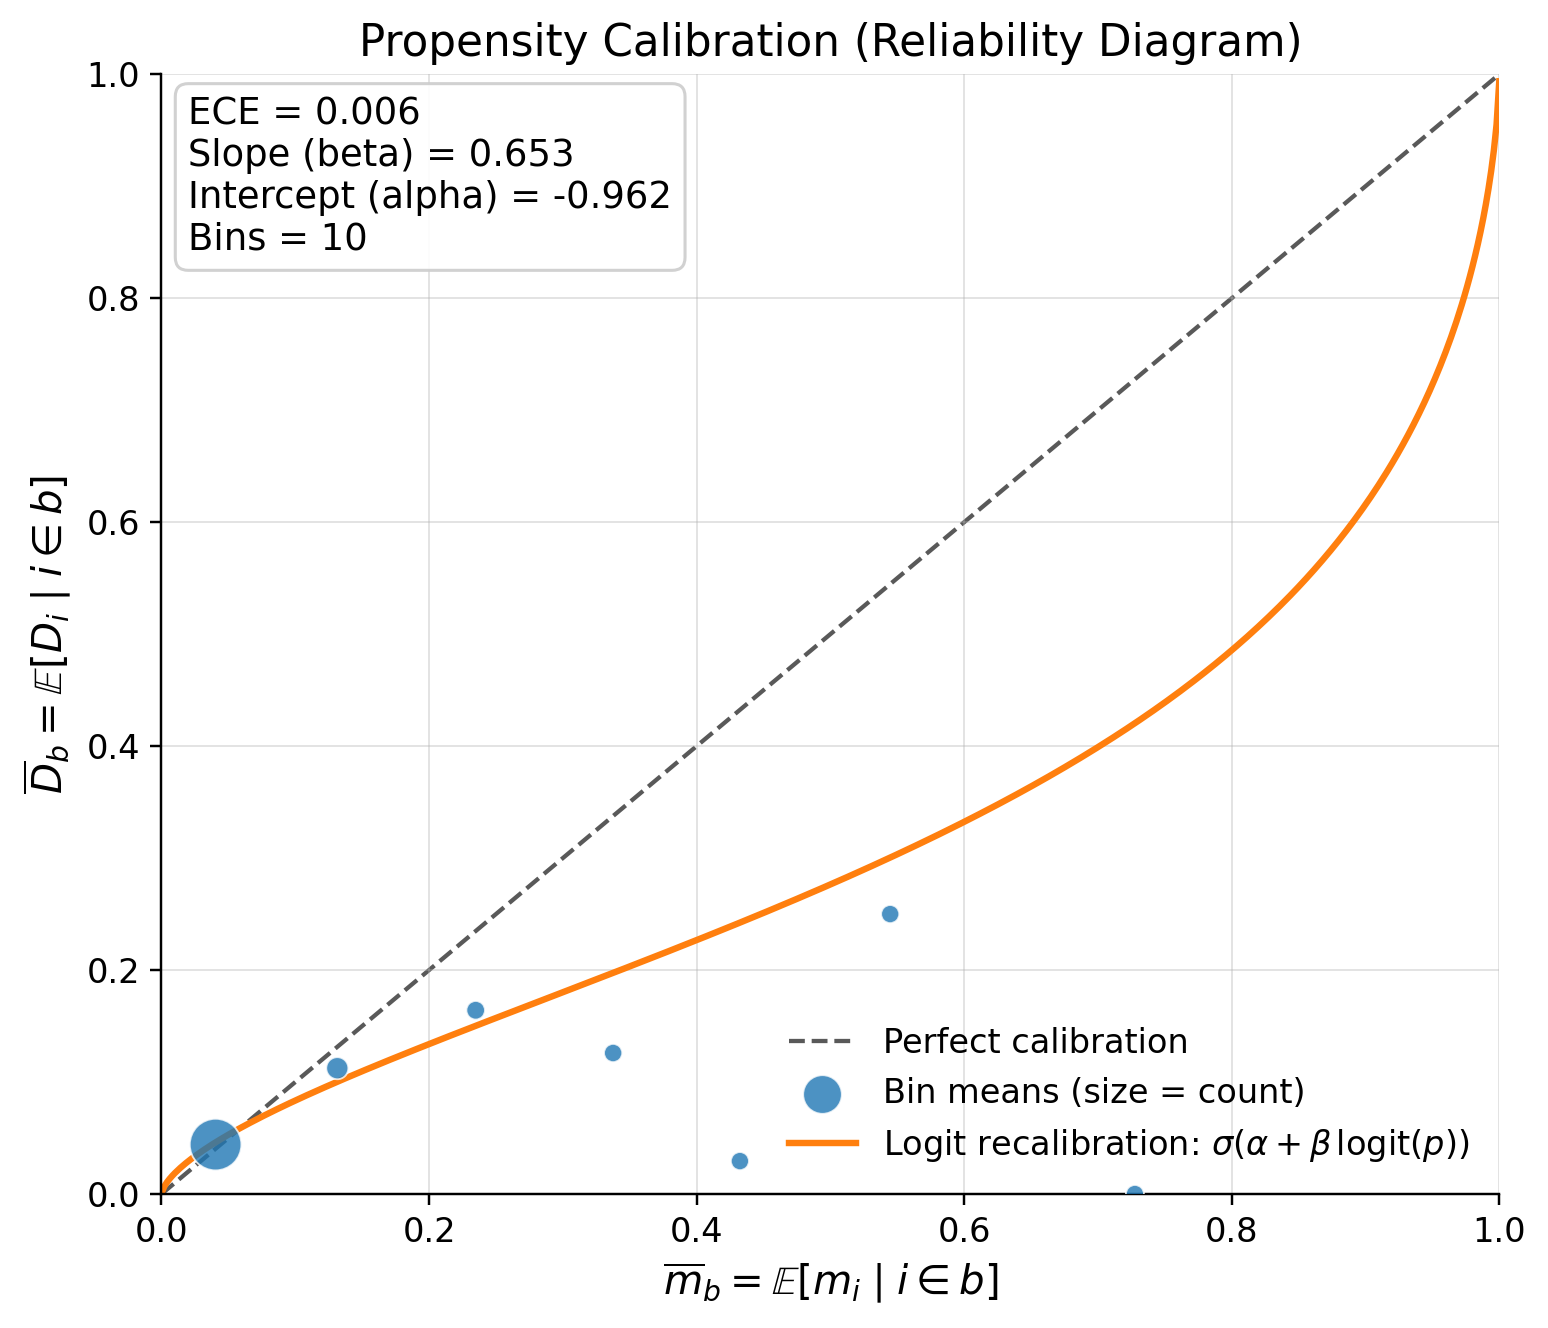

In [21]:
from causalis.scenarios.unconfoundedness.refutation import plot_propensity_reliability
plot_propensity_reliability(dml_result)

Logistic recalibration trend is a fitted correction curve for your predicted propensities.

The plot takes your original propensity p and fits this model:

corrected_p = sigmoid(alpha + beta * logit(p))
So the orange line answers:

If I recalibrate these predicted probabilities to better match observed treatment frequencies, what corrected probability would I use?

How to read it:

- If orange line matches the diagonal: predictions are already well calibrated
- If orange line is below the diagonal: model tends to overpredict treatment
- If orange line is above the diagonal: model tends to underpredict treatment

Rule of thumb:

- ECE near 0 and slope near 1: great
- ECE near 0 but slope far from 1: average calibration is fine, but probabilities are distorted in shape
- Many tiny bad bins + one huge good bin: visually noisy, but often not a major practical issue

Let's compare with oracle effect

In [22]:
print(f"Ground truth ATE is {data['cate'].mean()}")
print(f"Ground truth ATTE is {data[data['d'] == 1]['cate'].mean()}")

Ground truth ATE is 19.40958652966079
Ground truth ATTE is 10.914991423363862


# Conclusion

First purchase in our product is increasing LTV 11.7542 (ci_abs: 7.1434, 16.3651) dollars. Model is specified correctly and there is no evidence that assumptions are false